# Introduction to the Dataset

This is an introduction to the Sentinel-2 German national forest inventory dataset generated in in the frame of the Klimba project by Max Freudenberg, Sebastian Schnell and Paul Magdon.

The dataset contains the bottom of atmosphere reflectance values for the majority of the trees in the 2012 German national forest inventory.

For questions please refer to: maximilian.freudenberg@uni-goettingen.de

## Data Loading

In [1]:
import sqlite3
import datetime
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

The dataset comes in the form of an sqlite file. We first create an sqlite connection and tell sqlite to return strings as byte-arrays.

In [2]:
# change this path to point to the database file
dataset_path = 'data/S2GNFI_V1.sqlite'
conn = sqlite3.connect(dataset_path)
conn.text_factory = bytes  # this makes sqlite return strings as bytes that we can parse via numpy

To load the entire dataset, you need ~30 GB of RAM. But thanks to sqlite we can limit loading to a subset just to inspect a subset of the 
data. The data is stored in the sqlite table "data".

For demo purposes, we restrict loading to the classes spruce (10) and beech (100).

In [8]:
np.unique(df['species'])

array([ 10,  12,  19,  20,  22,  25,  30,  40,  50, 100, 110, 111, 120,
       130, 140, 141, 142, 150, 160, 170, 190, 193, 200, 211, 212, 220,
       221, 224, 230, 240, 251, 290, 293, 295])

In [6]:
df = pd.read_sql_query("SELECT * FROM data WHERE \
                       X_WGS84 between 10 and 11 and Y_WGS84 between 50 and 51 \
                       order by random() limit 100000", conn)

In [7]:
len(df)

100000

In [3]:
df = pd.read_sql_query("SELECT * FROM data WHERE \
                       (species=10 or species=100) and present_2022=TRUE and dbh_mm>200 and height_dm>120 \
                       order by random() limit 100000", conn)
df

,tnr,enr,tree_id,species,time,boa,qai,is_train,is_pure,dbh_mm,height_dm,crown_area_m2,X_WGS84,Y_WGS84,is_corrected,disturbance_year,present_2022,doy
0,588979,4,410977,10,1652140800,b'\xfd\x00\x96\x01\t\x01U\x02\xc0\x06\x19\x08\...,8192,0,0,410,290,28.411575,6.487152,50.431637,1.0,1995,1,130
1,56482,2,331449,10,1523923200,b'\x8f\x00\xec\x00\x90\x00-\x01\x92\x03\x96\x0...,24576,0,0,405,291,27.178995,10.698337,50.546219,1.0,0,1,107
2,56251,2,346557,10,1550102400,b'C\x00\xa6\x00E\x00\r\x01\x87\x03\x92\x04\xde...,10240,1,1,376,294,23.663857,10.585927,50.582809,1.0,0,1,45
3,6894,4,84872,10,1606089600,b'S\x00\xbe\x00n\x00G\x01\x03\x04\xf7\x04\xf3\...,10240,1,0,592,301,55.802258,9.058499,48.574913,0.0,0,1,328
4,15997,3,441699,10,1523145600,b'a\x00\xbe\x00s\x00\x88\x01\xcb\x03H\x05+\x05...,8192,1,0,672,376,71.141037,11.723040,50.013844,0.0,0,1,98
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,61054,1,498491,100,1557619200,b'\xdd\x00\xd7\x02\x16\x01-\x05Y\x0c|\x0e}\x0f...,8192,1,0,471,245,53.036015,7.446044,49.629375,1.0,0,1,132
99996,63006,4,472714,100,1483660800,b'\xb7\xd8\xb1\xdaK\xda\xea\xd8(\xd7\xf3\xd8\x...,14354,1,0,924,326,199.470810,7.535670,50.315044,1.0,0,1,6
99997,31554,2,252175,100,1631059200,b'\xbe\x00]\x01\xde\x00\xf2\x01\xd9\x06\x08\t\...,10240,0,0,258,246,15.953245,14.125248,53.984127,1.0,0,1,251
99998,53690,3,382494,10,1555027200,b'\xd6\x01f\x02+\x02G\x03\xa8\x05\xd4\x06&\x07...,8192,1,0,287,214,14.761886,14.120601,50.933495,1.0,0,1,102


The bottom of atmosphere (BOA) reflectances still look strange! That's because they are displayed as raw byte characters. We can easily convert the 20 byte values to 10 16 bit signed integers:

In [128]:
df.boa = [np.frombuffer(x, dtype=np.int16) for x in df.boa]
df

,tnr,enr,tree_id,species,time,boa,qai,is_pure,is_train,dbh_mm,height_dm,crown_area_m2,X_WGS84,Y_WGS84,is_corrected,disturbance_year,present_2022,doy
0,4001,2,109880,10,1480464000,"[61, 101, 57, 241, 767, 1022, 991, 1205, 281, ...",10240,0,1,571,337,52.271900,9.052762,48.160980,1.0,0,1,335
1,821523,2,370811,100,1626393600,"[209, 494, 249, 867, 3201, 3851, 3799, 3968, 1...",8192,0,1,733,310,126.077827,7.289723,51.415813,1.0,0,1,197
2,60960,3,369336,100,1539216000,"[254, 469, 283, 791, 2548, 3162, 3619, 3737, 1...",10240,0,0,542,276,69.587479,7.696764,49.598778,1.0,0,1,284
3,625799,3,405295,100,1630886400,"[158, 345, 180, 597, 2096, 2943, 3033, 3164, 1...",10240,1,1,671,373,106.412727,6.459611,50.610767,1.0,0,1,249
4,18650,3,206969,10,1483228800,"[285, 308, 223, 460, 1013, 1250, 1386, 1436, 5...",13312,1,0,491,326,39.367847,8.433148,51.203003,1.0,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,63076,3,500499,100,1549843200,"[293, 406, 451, 747, 1187, 1424, 1668, 1847, 1...",10240,1,0,308,316,22.391226,7.126088,50.350471,1.0,0,1,42
99996,16689,1,150561,100,1596585600,"[160, 382, 222, 650, 2199, 2937, 3024, 3413, 1...",8192,0,1,758,372,133.007431,7.818826,50.266827,1.0,0,1,218
99997,10069,1,153011,10,1660262400,"[137, 197, 142, 487, 1716, 2017, 2100, 2392, 1...",8192,0,0,322,233,18.413977,9.829119,49.028538,0.0,0,1,224
99998,2496,4,137867,10,1558656000,"[172, 354, 191, 554, 1480, 1694, 1737, 1884, 6...",8192,1,1,409,296,27.178995,9.244066,47.946491,1.0,0,1,144


Already looks much better! But what about the time?! Let's convert it from unix time to a human readable format.

In [129]:
df.time = [datetime.date.fromtimestamp(t) for t in df.time]
df

,tnr,enr,tree_id,species,time,boa,qai,is_pure,is_train,dbh_mm,height_dm,crown_area_m2,X_WGS84,Y_WGS84,is_corrected,disturbance_year,present_2022,doy
0,4001,2,109880,10,2016-11-30,"[61, 101, 57, 241, 767, 1022, 991, 1205, 281, ...",10240,0,1,571,337,52.271900,9.052762,48.160980,1.0,0,1,335
1,821523,2,370811,100,2021-07-16,"[209, 494, 249, 867, 3201, 3851, 3799, 3968, 1...",8192,0,1,733,310,126.077827,7.289723,51.415813,1.0,0,1,197
2,60960,3,369336,100,2018-10-11,"[254, 469, 283, 791, 2548, 3162, 3619, 3737, 1...",10240,0,0,542,276,69.587479,7.696764,49.598778,1.0,0,1,284
3,625799,3,405295,100,2021-09-06,"[158, 345, 180, 597, 2096, 2943, 3033, 3164, 1...",10240,1,1,671,373,106.412727,6.459611,50.610767,1.0,0,1,249
4,18650,3,206969,10,2017-01-01,"[285, 308, 223, 460, 1013, 1250, 1386, 1436, 5...",13312,1,0,491,326,39.367847,8.433148,51.203003,1.0,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,63076,3,500499,100,2019-02-11,"[293, 406, 451, 747, 1187, 1424, 1668, 1847, 1...",10240,1,0,308,316,22.391226,7.126088,50.350471,1.0,0,1,42
99996,16689,1,150561,100,2020-08-05,"[160, 382, 222, 650, 2199, 2937, 3024, 3413, 1...",8192,0,1,758,372,133.007431,7.818826,50.266827,1.0,0,1,218
99997,10069,1,153011,10,2022-08-12,"[137, 197, 142, 487, 1716, 2017, 2100, 2392, 1...",8192,0,0,322,233,18.413977,9.829119,49.028538,0.0,0,1,224
99998,2496,4,137867,10,2019-05-24,"[172, 354, 191, 554, 1480, 1694, 1737, 1884, 6...",8192,1,1,409,296,27.178995,9.244066,47.946491,1.0,0,1,144


## Quality Filtering

As you might have noticed, there is a QAI column, which stands for quality assurance information. This information is output by the [FORCE](https://force-eo.readthedocs.io/) satellite image processing suite. The different image conditions are encoded bit-wise in a single unsigned 16 bit integer, as documented [here](https://force-eo.readthedocs.io/en/latest/howto/qai.html#quality-bits-in-force).

For convenience, here are the different bit-masks in python code:

In [130]:
VALID        = 0b000000000000000
NODATA       = 0b000000000000001
CLOUD_BUFFER = 0b000000000000010
CLOUD_OPAQUE = 0b000000000000100
CLOUD_CIRRUS = 0b000000000000110
CLOUD_SHADOW = 0b000000000001000
SNOW         = 0b000000000010000
WATER        = 0b000000000100000
AOD_INT      = 0b000000001000000
AOD_HIGH     = 0b000000010000000
AOD_FILL     = 0b000000011000000
SUBZERO      = 0b000000100000000
SATURATION   = 0b000001000000000
SUN_LOW      = 0b000010000000000
ILLUMIN_LOW  = 0b000100000000000
ILLUMIN_POOR = 0b001000000000000
ILLUMIN_NONE = 0b001100000000000
SLOPED       = 0b010000000000000
WVP_NONE     = 0b100000000000000

Let's now look at the QAI value of the first record:

In [131]:
df["qai"][0]

10240

...and convert this value to binary representation:

In [132]:
bin(10240)

'0b10100000000000'

Now we can count the position of the 1, starting from the right - the 1 is in position 14. Comparing this with the table above tells us, that the area is sloped. Let's check that:

In [ ]:
SLOPED

Correct!

Let's perform a simple check: Are there any pixels in our dataset that FORCE detected as water or snow? To do so, we can combine the different bit flags using the "logical or" operator "|". This compares two values and sets a bit where either a or b has a bit set.

In [133]:
my_filter = SNOW | WATER
my_filter

48

In [134]:
bin(my_filter)

'0b110000'

We have now created a value that has two 1s in positions 5 and 6.

If we now want to find out whether some of the QAI values matches our filter, we simply have to check whether there is a 1 in the same positions as in our filter. We do this by the "logical and" operator "&" that sets a bit if the QAI value *and* our filter have a bit set in the same position. Naturally, any bit set to 1 will yield a number larger zero.

In [137]:
mask = (df["qai"] & my_filter) > 0
mask

0        False
1        False
2        False
3        False
4        False
         ...  
99995    False
99996    False
99997    False
99998    False
99999    False
Name: qai, Length: 100000, dtype: bool

In [138]:
np.sum(mask)

1900

-> There are 1795 spruce and beech records in the subset that we have loaded where FORCE recognized water or snow. Water of course makes no sense, because the measured trees are on land, but is obvousily possible in winter.

Let's now remove all types of cloud and snow from our dataset by comparing each QAI value with a filter by the logical and operator. If the QAI values and the filter have no common bits the resulting value is zero - these are the cloud free records we are interested in.

In [139]:
my_filter = CLOUD_BUFFER | CLOUD_CIRRUS | CLOUD_OPAQUE | CLOUD_SHADOW | SNOW
mask = (df["qai"] & my_filter) == 0
df = df[mask]

**Use logical or "|" to combine filter values, logical and "&" to compare the filter with the QAI flag and check whether the result is zero to include all valid records.**

## Plotting

Let's plot the time series of our records for beech for the Sentinel-2 band B8. You find an overview of the Sentinel-2 bands [here](https://gisgeography.com/sentinel-2-bands-combinations/).

<table><tbody><tr><th>Band</th><th>Resolution</th><th>Central Wavelength</th><th>Description</th></tr><tr><td>B1</td><td>60 m</td><td>443 nm</td><td>Ultra Blue (Coastal and Aerosol)</td></tr><tr><td>B2</td><td>10 m</td><td>490 nm</td><td>Blue</td></tr><tr><td>B3</td><td>10 m</td><td>560 nm</td><td>Green</td></tr><tr><td>B4</td><td>10 m</td><td>665 nm</td><td>Red</td></tr><tr><td>B5</td><td>20 m</td><td>705 nm</td><td>Visible and Near Infrared (VNIR)</td></tr><tr><td>B6</td><td>20 m</td><td>740 nm</td><td>Visible and Near Infrared (VNIR)</td></tr><tr><td>B7</td><td>20 m</td><td>783 nm</td><td>Visible and Near Infrared (VNIR)</td></tr><tr><td>B8</td><td>10 m</td><td>842 nm</td><td>Visible and Near Infrared (VNIR)</td></tr><tr><td>B8a</td><td>20 m</td><td>865 nm</td><td>Visible and Near Infrared (VNIR)</td></tr><tr><td>B9</td><td>60 m</td><td>940 nm</td><td>Short Wave Infrared (SWIR)</td></tr><tr><td>B10</td><td>60 m</td><td>1375 nm</td><td>Short Wave Infrared (SWIR)</td></tr><tr><td>B11</td><td>20 m</td><td>1610 nm</td><td>Short Wave Infrared (SWIR)</td></tr><tr><td>B12</td><td>20 m</td><td>2190 nm</td><td>Short Wave Infrared (SWIR)</td></tr></tbody></table>

FORCE uses all bands with 10 or 20 meters resolution. So to get Sentinel band 8 we have to select the band with index 6 in our dataset. (Python indexing starts at 0.)

In [140]:
df["b8"] = [boa[6] for boa in df["boa"]]

<ipython-input-140-eacf9b8024fe>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["b8"] = [boa[6] for boa in df["boa"]]


Now let's group the values based on the time and species.

In [141]:
species_groups = df[["time", "species", "b8"]].groupby("species")
grouped_df_beech = species_groups.get_group(100).groupby("time")

In [142]:
grouped_df_beech.get_group(datetime.date(2022,3,5))

,time,species,b8
1342,2022-03-05,100,1686
5800,2022-03-05,100,998
10791,2022-03-05,100,1703
11690,2022-03-05,100,2013
14808,2022-03-05,100,1643
17627,2022-03-05,100,1681
23206,2022-03-05,100,1634
24015,2022-03-05,100,1097
28275,2022-03-05,100,1538
31569,2022-03-05,100,1889


In [143]:
averaged_series = grouped_df_beech.mean()["b8"]
averaged_series

time
2015-07-01    4610.714286
2015-07-02    3734.125000
2015-07-03    2264.000000
2015-07-04    4016.500000
2015-07-05    4497.250000
                 ...     
2022-10-28    2127.368421
2022-10-29    2218.833333
2022-10-30    2025.750000
2022-10-31    2616.800000
2022-11-02    1851.500000
Name: b8, Length: 2365, dtype: float64

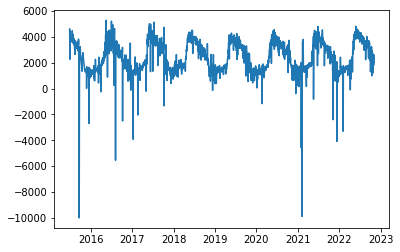

In [144]:
plt.plot(averaged_series)

Oh what is this? There are still negative values! We forgot to filter for NODATA values. While we're at it, let's also remove pixels with high aerosol optical depth.

In [145]:
my_filter = NODATA | CLOUD_BUFFER | CLOUD_CIRRUS | CLOUD_OPAQUE | CLOUD_SHADOW | SNOW | AOD_HIGH | AOD_FILL | AOD_INT
mask = (df["qai"] & my_filter) == 0
df = df[mask]

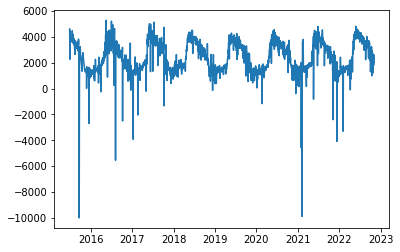

In [147]:
# let's plot it again
averaged_series = grouped_df_beech.mean()["b8"]
plt.plot(averaged_series)

Some outlier values are still present, so we'll simply remove all values below zero, because negative reflectances are unphysical. Furthermore, we can divide the BOA value by 100 to obtain the BOA reflectance in %.

Text(0, 0.5, 'BOA Reflectance [%]')

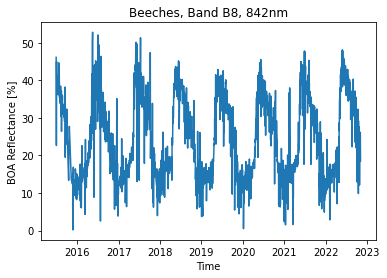

In [148]:
averaged_series = grouped_df_beech.mean().query("b8 > 0")["b8"]
averaged_series /= 100
plt.plot(averaged_series)
plt.title("Beeches, Band B8, 842nm")
plt.xlabel("Time")
plt.ylabel("BOA Reflectance [%]")

### Comparison between spruce and beech

In [149]:
my_filter = NODATA | CLOUD_BUFFER | CLOUD_CIRRUS | CLOUD_OPAQUE | CLOUD_SHADOW | SNOW | AOD_HIGH | AOD_FILL | AOD_INT
mask = (df["qai"] & my_filter) == 0
df = df[mask]

In [150]:
species_groups = df[["time", "species", "b8"]].groupby("species")
grouped_df_beech  = species_groups.get_group(100).groupby("time")
grouped_df_spruce = species_groups.get_group(10).groupby("time")

avg_beech = grouped_df_beech.mean().query("b8 > 0")["b8"] / 100
avg_spruce = grouped_df_spruce.mean().query("b8 > 0")["b8"] / 100

Text(0, 0.5, 'BOA Reflectance [%]')

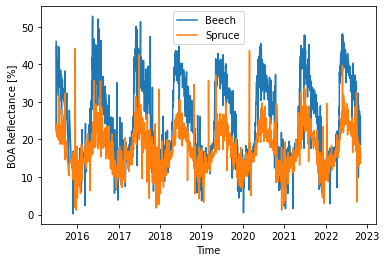

In [151]:
plt.plot(avg_beech, label="Beech")
plt.plot(avg_spruce, label="Spruce")
plt.legend()
plt.xlabel("Time")
plt.ylabel("BOA Reflectance [%]")

We see that the data is relatively noisy. This is because we have loaded only a subset of the dataset. Loading all the data takes some time but would improve the result.

## NDVI

To explore the data even more, we can take a look at the NDVI. We define the NDVI via the red and near infrared bands (see above table). Python indexing starts at 0 and we skip all bands that have a lower resolution than 20m. We select the 842nm band, because it has 10m resolution, like the red band.

In [152]:
def ndvi(boa):
    boa32 = boa.astype(np.float32)
    return (boa32[6] - boa32[3]) / (boa32[6] + boa32[3] + np.float32(1e-8))

In [153]:
df["ndvi"] = df["boa"].apply(ndvi)

In [154]:
df

,tnr,enr,tree_id,species,time,boa,qai,is_pure,is_train,dbh_mm,height_dm,crown_area_m2,X_WGS84,Y_WGS84,is_corrected,disturbance_year,present_2022,doy,b8,ndvi
0,4001,2,109880,10,2016-11-30,"[61, 101, 57, 241, 767, 1022, 991, 1205, 281, ...",10240,0,1,571,337,52.271900,9.052762,48.160980,1.0,0,1,335,991,0.608766
1,821523,2,370811,100,2021-07-16,"[209, 494, 249, 867, 3201, 3851, 3799, 3968, 1...",8192,0,1,733,310,126.077827,7.289723,51.415813,1.0,0,1,197,3799,0.628375
2,60960,3,369336,100,2018-10-11,"[254, 469, 283, 791, 2548, 3162, 3619, 3737, 1...",10240,0,0,542,276,69.587479,7.696764,49.598778,1.0,0,1,284,3619,0.641270
3,625799,3,405295,100,2021-09-06,"[158, 345, 180, 597, 2096, 2943, 3033, 3164, 1...",10240,1,1,671,373,106.412727,6.459611,50.610767,1.0,0,1,249,3033,0.671074
4,18650,3,206969,10,2017-01-01,"[285, 308, 223, 460, 1013, 1250, 1386, 1436, 5...",13312,1,0,491,326,39.367847,8.433148,51.203003,1.0,0,1,1,1386,0.501625
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99994,16447,3,146039,10,2019-04-09,"[357, 472, 359, 591, 1155, 1398, 1493, 1566, 6...",8192,0,0,518,308,42.411255,12.176234,50.158989,1.0,0,1,99,1493,0.432821
99995,63076,3,500499,100,2019-02-11,"[293, 406, 451, 747, 1187, 1424, 1668, 1847, 1...",10240,1,0,308,316,22.391226,7.126088,50.350471,1.0,0,1,42,1668,0.381366
99996,16689,1,150561,100,2020-08-05,"[160, 382, 222, 650, 2199, 2937, 3024, 3413, 1...",8192,0,1,758,372,133.007431,7.818826,50.266827,1.0,0,1,218,3024,0.646162
99997,10069,1,153011,10,2022-08-12,"[137, 197, 142, 487, 1716, 2017, 2100, 2392, 1...",8192,0,0,322,233,18.413977,9.829119,49.028538,0.0,0,1,224,2100,0.623502


In [155]:
my_filter = NODATA | CLOUD_BUFFER | CLOUD_CIRRUS | CLOUD_OPAQUE | CLOUD_SHADOW | SNOW | AOD_HIGH | AOD_FILL | AOD_INT
mask = (df["qai"] & my_filter) == 0
df = df[mask]
ndvi_beech  = df[["time", "species", "ndvi"]].query("species == 100 and -1 < ndvi < 1").groupby("time").mean()["ndvi"]
ndvi_spruce = df[["time", "species", "ndvi"]].query("species == 10 and -1 < ndvi < 1").groupby("time").mean()["ndvi"]

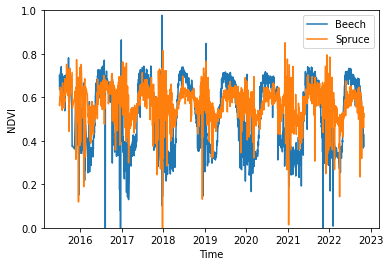

In [156]:
plt.plot(ndvi_beech, label="Beech")
plt.plot(ndvi_spruce, label="Spruce")
plt.ylim(0,1)
plt.xlabel("Time")
plt.ylabel("NDVI")
plt.legend()

## Conclusion

There are far more analyses possible with this dataset and we encourage you to try them out! Should you encounter any issues or inconsistencies with the dataset itself, don't hesitate to contact the authors.

In [9]:
# Let's examine the Landsat TM parameters file for Germany
import os

# Define the path to the parameter file
param_file_path = "data/germany-operational-landsat-tm.prm"

# Check if the file exists
if os.path.exists(param_file_path):
    # Read and display the contents of the parameter file
    with open(param_file_path, 'r') as file:
        param_content = file.read()
        print(f"Contents of {param_file_path}:\n")
        print(param_content)
else:
    print(f"File not found: {param_file_path}")
    
    # List available files in the data directory to help locate the correct file
    data_dir = "data"
    if os.path.exists(data_dir):
        print(f"\nAvailable files in {data_dir} directory:")
        for file in os.listdir(data_dir):
            print(f"  - {file}")
    else:
        print(f"\nThe {data_dir} directory does not exist.")


Contents of data/germany-operational-landsat-tm.prm:

{"payload":{"allShortcutsEnabled":false,"fileTree":{"force-param":{"items":[{"name":"Readme.md","path":"force-param/Readme.md","contentType":"file"},{"name":"germany-operational-landsat-oli.prm","path":"force-param/germany-operational-landsat-oli.prm","contentType":"file"},{"name":"germany-operational-landsat-tm.prm","path":"force-param/germany-operational-landsat-tm.prm","contentType":"file"},{"name":"germany-operational-sentinel2.prm","path":"force-param/germany-operational-sentinel2.prm","contentType":"file"}],"totalCount":4},"":{"items":[{"name":"force-param","path":"force-param","contentType":"directory"},{"name":".gitignore","path":".gitignore","contentType":"file"},{"name":"Manifest.toml","path":"Manifest.toml","contentType":"file"},{"name":"Project.toml","path":"Project.toml","contentType":"file"},{"name":"Readme.md","path":"Readme.md","contentType":"file"},{"name":"cut_tiles_from_forcecube.jl","path":"cut_tiles_from_forcecu

In [16]:
# Let's read the ESSD table data
import pandas as pd
import openpyxl

# Define the path to the Excel file
excel_file_path = "data/essd-17-351-2025-t04.xlsx"

# Check if the file exists
if os.path.exists(excel_file_path):
    # Read the Excel file
    essd_table = pd.read_excel(excel_file_path)
    
    # Display the first few rows of the table
    print(f"Contents of {excel_file_path}:\n")
    display(essd_table.head())
    
    # Display basic information about the table
    print("\nTable information:")
    print(f"Number of rows: {len(essd_table)}")
    print(f"Number of columns: {len(essd_table.columns)}")
    print("\nColumn names:")
    for col in essd_table.columns:
        print(f"  - {col}")
print(np.unique(essd_table['Common name']))


Contents of data/essd-17-351-2025-t04.xlsx:



,Species code,Species,Unnamed: 2,Common name,Count
0,−1,–,–,Other land cover,70 242
1,10,Picea,abies,Norway spruce,107 798
2,12,Picea,sitchensis,Sitka spruce,937
3,19,Picea,spec.,Other spruces,232
4,20,Pinus,sylvestris,Scots pine,102 730



Table information:
Number of rows: 52
Number of columns: 5

Column names:
  - Species code
  - Species
  - Unnamed: 2
  - Common name
  - Count
['Balsam poplar' 'Beech' 'Bird cherry' 'Black alder' 'Black cherry'
 'Black locust' 'Chestnut' 'Common ash' 'Common aspen' 'Common whitebeam'
 'Douglas fir' 'Eastern white pine' 'Elm, native species' 'English oak'
 'European black pine' 'European black poplar (+\u2009hybrids)'
 'European crab apple' 'European larch' 'European rowan'
 'European wild pear' 'European yew' 'Field maple' 'Grand fir'
 'Grey alder' 'Grey poplar (+\u2009hybrids)' 'Hornbeam'
 'Japanese larch (+\u2009hybrids)' 'Linden tree (indigenous species)'
 'Miscellaneous broadleaf trees with a long life expectancy'
 'Miscellaneous broadleaf trees with a short life expectancy' 'Moor birch'
 'Mountain pine' 'Northern red oak' 'Norway maple' 'Norway spruce'
 'Other coniferous trees' 'Other firs' 'Other land cover' 'Other pines'
 'Other spruces' 'Scots pine' 'Service tree' 'Sessile oa